In [88]:
# Importing the necessary libraries
import numpy as np
import matplotlib.pyplot as plt
import torchvision
from sklearn.manifold import TSNE

plt.rcParams['figure.figsize'] = 10, 10

In [89]:
train_dataset = torchvision.datasets.MNIST(
    root="./MNIST/train", train=True,
    transform=torchvision.transforms.ToTensor(),
    download=True)

test_dataset = torchvision.datasets.MNIST(
    root="./MNIST/test", train=False,
    transform=torchvision.transforms.ToTensor(),
    download=True)


In [90]:
def encode_label(j):
    # 5 -> [[0], [0], [0], [0], [0], [1], [0], [0], [0], [0]]
    e = np.zeros((10,1))
    e[j] = 1.0
    return e

def shape_data(data):
    features = [np.reshape(x[0][0].numpy(), (784,1)) for x in data]
    labels = [encode_label(y[1]) for y in data]
    return zip(features, labels)

In [91]:
train = shape_data(train_dataset)
test = shape_data(test_dataset)

train imgs - 60000
test imgs - 10000


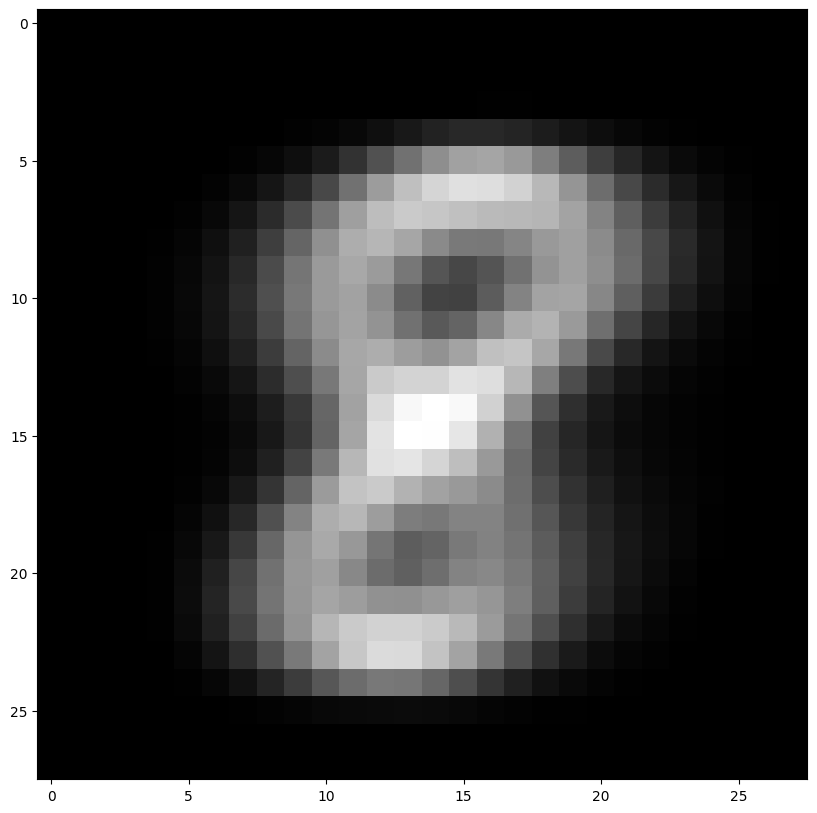

W_avg shape: (10, 784)


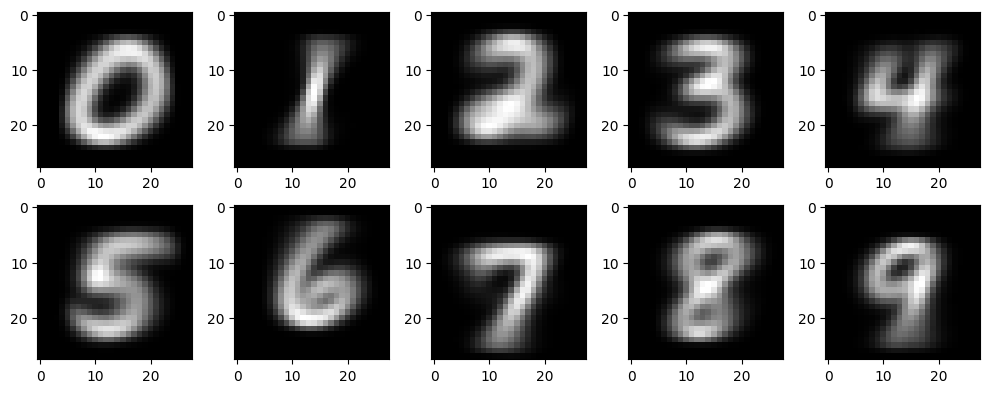

In [92]:
def average_digit(data, digit):
    filtered_data = [x[0] for x in data if np.argmax(x[1]) == digit]
    filtered_array = np.asarray(filtered_data)          
    return np.average(filtered_array, axis=0)     

train = list(train)
test = list(test)
print('train imgs -', len(train))
print('test imgs -', len(test))

# Средняя картинка для восьмёрки 
avg_eight = average_digit(train, 8)

img_eight = np.reshape(avg_eight, (28, 28))
plt.imshow(img_eight, cmap='gray')
plt.show()

# Считаем средние для всех цифр 0-9
average_digits = [average_digit(train, d) for d in range(10)]
# average_digits[d] – средний вектор для цифры d (shape примерно (784,1) или (784,))

# Строим матрицу весов (10, 784) 
W_avg = np.vstack([avg.reshape(1, -1) for avg in average_digits])
print("W_avg shape:", W_avg.shape) 

fig, axes = plt.subplots(2, 5, figsize=(10, 4))

for d in range(10):
    img = average_digits[d].reshape(28, 28)
    ax = axes[d // 5, d % 5]
    ax.imshow(img, cmap='gray')

plt.tight_layout()
plt.show()

In [93]:
X_train = np.hstack([x for (x, y) in train])
y_train = np.array([np.argmax(y) for (x, y) in train])

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

# Считаем скалярное произведение средних картинок со всеми объектами
# scores[d, i] = <avg_digit_d, x_i>
scores = W_avg @ X_train      
print("scores shape:", scores.shape)

# Строим bias для каждого из 10 классификаторов
b_avg = np.zeros(10)

for d in range(10):
    # все скоры для класса d
    pos_scores = scores[d, y_train == d]    # "свои" объекты
    neg_scores = scores[d, y_train != d]    # "чужие" объекты

    # Порог = середина между средними "своих" и "чужих" скоров
    thr = 0.5 * (pos_scores.mean() + neg_scores.mean())
    b_avg[d] = -thr                         

print("b_avg:", b_avg)


# 10 бинарных классификаторов 

def classifier_digit(x, digit):
    """
    Бинарный классификатор для одной цифры.
    x      : вектор признаков 784×1
    digit  : число от 0 до 9
    return : 1, если считаем, что картинка — это digit, иначе 0
    """
    w = W_avg[digit].reshape(1, -1)            
    s = float(w @ x.reshape(784, 1)) + b_avg[digit]
    return 1 if s >= 0 else 0


def predict_10(x):
    """
    Одновременный запуск всех 10 бинарных классификаторов.
    x         : 784×1
    return:
        binary (np.array shape (10,)): выходы из 10 классификаторов (0/1)
        label  (int)                 : предсказанная цифра (argmax по скору)
    """
    x_vec = x.reshape(784, 1)
    logits = (W_avg @ x_vec).flatten() + b_avg   
    binary = (logits >= 0).astype(int)
    label = int(np.argmax(logits))
    return binary, label


# Пример на одном объекте из теста

x_test, y_test = test[0]
binary_out, pred_label = predict_10(x_test)

print("True label      :", int(np.argmax(y_test)))
print("Binary outputs  :", binary_out)
print("Predicted label :", pred_label)


# оценка точности на всём тестовом наборе
# def evaluate(test_data):
#     correct = 0
#     total = 0
#     for x, y in test_data:
#         _, pred = predict_10(x)
#         if pred == int(np.argmax(y)):
#             correct += 1
#         total += 1
#     print("Accuracy on test:", correct / total)

X_train shape: (784, 60000)
y_train shape: (60000,)
scores shape: (10, 60000)
b_avg: [-53.16246033 -25.97997284 -43.16940308 -43.10486603 -36.17195892
 -35.66538239 -42.23587799 -35.03879547 -47.76631546 -38.89998245]
True label      : 7
Binary outputs  : [0 0 0 0 0 0 0 1 0 0]
Predicted label : 7


In [94]:
# Точность каждого из 10 бинарных классификаторов

def accuracy_per_classifier(test_data):
    """
    Возвращает список из 10 accuracy: по одному для каждого бинарного классификатора.
    """
    accuracies = []

    for digit in range(10):
        TP = TN = FP = FN = 0

        for x, y in test_data:
            true_digit = int(np.argmax(y))
            pred = classifier_digit(x, digit)

            if true_digit == digit and pred == 1:
                TP += 1
            elif true_digit != digit and pred == 0:
                TN += 1
            elif true_digit != digit and pred == 1:
                FP += 1
            elif true_digit == digit and pred == 0:
                FN += 1

        acc = (TP + TN) / (TP + TN + FP + FN)
        accuracies.append(acc)

    return accuracies


acc_list = accuracy_per_classifier(test)
for d, acc in enumerate(acc_list):
    print(f"Digit {d}: accuracy = {acc:.4f}")

/tmp/ipykernel_23507/2813808567.py:37: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  s = float(w @ x.reshape(784, 1)) + b_avg[digit]


Digit 0: accuracy = 0.8365
Digit 1: accuracy = 0.6459
Digit 2: accuracy = 0.7240
Digit 3: accuracy = 0.7274
Digit 4: accuracy = 0.6263
Digit 5: accuracy = 0.5865
Digit 6: accuracy = 0.7323
Digit 7: accuracy = 0.6675
Digit 8: accuracy = 0.7309
Digit 9: accuracy = 0.6487


In [95]:
# Модель из 10 классификаторов

class AvgDigitModel:
    def __init__(self, W, b):
        """
        W : матрица весов среднего вида цифр, shape (10, 784)
        b : вектор bias'ов, shape (10,)
        """
        self.W = W          
        self.b = b          

    def logits(self, x):
        """
        Сырые скоры (до порога): 10 чисел, по одному для каждой цифры.
        x : 784×1 или 28×28 
        return: np.array shape (10,)
        """
        x_vec = x.reshape(784, 1)                  
        return (self.W @ x_vec).flatten() + self.b 

    def predict_vector(self, x):
        """
        Возвращает one-hot вектор длины 10.
        Например, если модель считает, что это '3':
        [0, 0, 0, 1, 0, 0, 0, 0, 0, 0]^T
        """
        l = self.logits(x)             
        k = int(np.argmax(l))          
        y = np.zeros((10, 1), dtype=int)
        y[k, 0] = 1
        return y

    def predict_label(self, x):
        """
        Просто цифра 0-9
        """
        l = self.logits(x)
        return int(np.argmax(l))


model = AvgDigitModel(W_avg, b_avg)

# Пример: первая картинка из теста
x_test, y_test = test[0]
vec = model.predict_vector(x_test)
label_pred = model.predict_label(x_test)

print("Истинная цифра :", int(np.argmax(y_test)))
print("Вектор модели  :\n", vec.T)
print("Предсказанная  :", label_pred)


Истинная цифра : 7
Вектор модели  :
 [[0 0 0 0 0 0 0 1 0 0]]
Предсказанная  : 7


In [96]:
# Precision и Recall для 10-классовой модели

def precision_recall(model, test_data):
    """
    Возвращает два списка длиной 10:
    precision[d], recall[d]
    """
    TP = [0]*10
    FP = [0]*10
    FN = [0]*10
    TN = [0]*10

    for x, y in test_data:
        true_digit = int(np.argmax(y))
        pred_digit = model.predict_label(x)

        for d in range(10):
            if pred_digit == d and true_digit == d:
                TP[d] += 1
            elif pred_digit == d and true_digit != d:
                FP[d] += 1
            elif pred_digit != d and true_digit == d:
                FN[d] += 1
            else:
                TN[d] += 1

    precision = []
    recall = []

    for d in range(10):
        p = TP[d] / (TP[d] + FP[d]) if TP[d] + FP[d] > 0 else 0
        r = TP[d] / (TP[d] + FN[d]) if TP[d] + FN[d] > 0 else 0
        precision.append(p)
        recall.append(r)

    return precision, recall


prec, rec = precision_recall(model, test)

for d in range(10):
    print(f"Digit {d}: precision = {prec[d]:.4f}, recall = {rec[d]:.4f}")


Digit 0: precision = 0.9203, recall = 0.8245
Digit 1: precision = 0.4996, recall = 0.9947
Digit 2: precision = 0.9132, recall = 0.6318
Digit 3: precision = 0.8069, recall = 0.7158
Digit 4: precision = 0.7181, recall = 0.8666
Digit 5: precision = 0.6619, recall = 0.6693
Digit 6: precision = 0.8925, recall = 0.8058
Digit 7: precision = 0.7991, recall = 0.8473
Digit 8: precision = 0.9454, recall = 0.4446
Digit 9: precision = 0.8471, recall = 0.6313


X_tsne shape: (300, 784)
y_tsne shape: (300,)


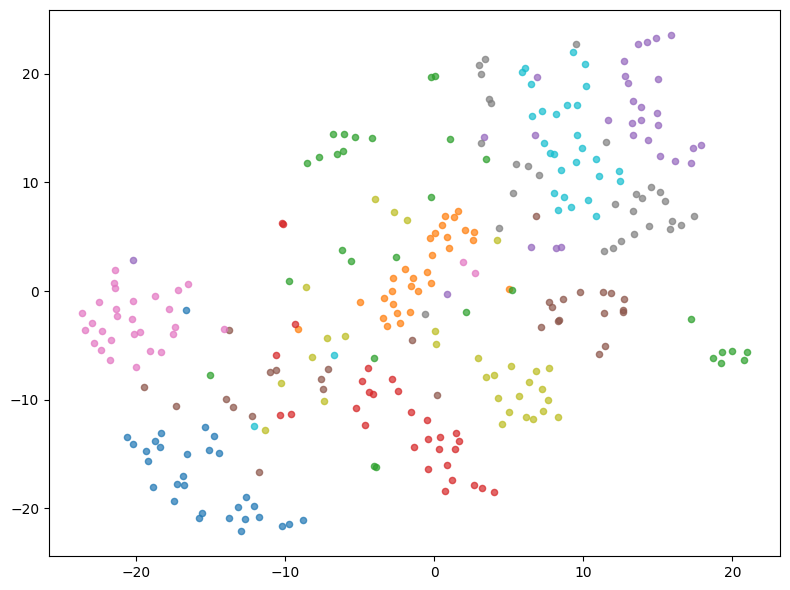

In [97]:
def collect_samples_per_class(data, n_per_class=30):
    """
    data: список пар (x, y), где
          x — вектор 784×1
          y — one-hot 10×1
    n_per_class: сколько картинок на класс брать

    return:
        X  — np.array shape (10*n_per_class, 784)
        y  — np.array shape (10*n_per_class,)
    """
    X_list = []
    y_list = []
    counts = {d: 0 for d in range(10)}

    for x, y in data:
        digit = int(np.argmax(y))   

        if counts[digit] < n_per_class:
            X_list.append(x.reshape(784))  
            y_list.append(digit)
            counts[digit] += 1

        # если набрали по n_per_class для всех цифр - выходим
        if all(counts[d] >= n_per_class for d in range(10)):
            break

    X = np.vstack(X_list)     
    y = np.array(y_list)      
    return X, y


X_tsne, y_tsne = collect_samples_per_class(train, n_per_class=30)
print("X_tsne shape:", X_tsne.shape)   
print("y_tsne shape:", y_tsne.shape)   

# Запуск t-SNE
tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate=200,
    max_iter=1000,        
    init="random",
    random_state=42,
)

X_embedded = tsne.fit_transform(X_tsne)

# Визуализация
plt.figure(figsize=(8, 6))

for d in range(10):
    idx = (y_tsne == d)
    plt.scatter(
        X_embedded[idx, 0],
        X_embedded[idx, 1],
        s=20,
        alpha=0.7,
        label=str(d)
    )

plt.tight_layout()
plt.show()


Z_logits shape: (300, 10)
y_logits shape: (300,)


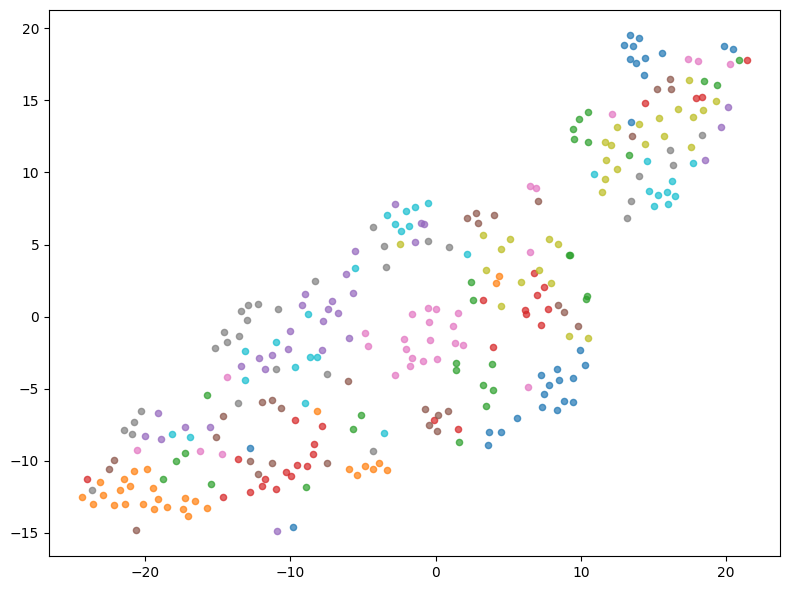

In [98]:
def collect_logits_per_class(model, data, n_per_class=30):
    """
    model: модель AvgDigitModel
    data : список (x, y), где x — 784×1, y — one-hot 10×1
    n_per_class: сколько картинок на класс брать

    return:
        Z  — np.array shape (10*n_per_class, 10)  (логиты)
        y  — np.array shape (10*n_per_class,)     (истинные цифры)
    """
    Z_list = []
    y_list = []
    counts = {d: 0 for d in range(10)}

    for x, y in data:
        digit = int(np.argmax(y))

        if counts[digit] < n_per_class:
            logits_vec = model.logits(x)          
            Z_list.append(logits_vec.reshape(1, -1))
            y_list.append(digit)
            counts[digit] += 1

        if all(counts[d] >= n_per_class for d in range(10)):
            break

    Z = np.vstack(Z_list)     
    y = np.array(y_list)     
    return Z, y

Z_logits, y_logits = collect_logits_per_class(model, test, n_per_class=30)
print("Z_logits shape:", Z_logits.shape)   
print("y_logits shape:", y_logits.shape)   

# t-SNE в пространстве логитов 
tsne_logits = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate=200,
    max_iter=1000,        
    init="random",
    random_state=42,
)

Z_embedded = tsne_logits.fit_transform(Z_logits)   


# Визуализация
plt.figure(figsize=(8, 6))

for d in range(10):
    idx = (y_logits == d)
    plt.scatter(
        Z_embedded[idx, 0],
        Z_embedded[idx, 1],
        s=20,
        alpha=0.7,
        label=str(d)
    )

plt.tight_layout()
plt.show()
